# Compare saved evaluation runs

Every `language-id eval` run is saved under `results/<model>_<dataset>_<timestamp>/` with its metrics, per-language scores, and plots. This notebook loads several of those **already-computed** runs back from disk and compares them side by side for post-evaluation analysis.

For example, this can be useful to answer: *given the same dataset / experiment setup, which model was best overall, and where does each one win or lose per language?*

Only runs on the **same dataset with the same per-language support** to provide a fair comparison.

## Setup

In [1]:
import matplotlib.pyplot as plt

%matplotlib inline

from language_id.compare_experiments import (
    RESULTS_ROOT,
    check_comparable,
    discover_runs,
    load_runs,
    overview_table,
    per_language_pivot,
    plot_disagreement,
    plot_overview,
    plot_per_language_heatmap,
    style_overview,
    style_per_language,
)

# Comparison figures from this notebook are written here.
FIG_DIR = RESULTS_ROOT / "comparisons"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Pick the runs to compare

`discover_runs()` lists every saved run id (newest first). Copy the ones you want into `RUN_IDS` below. They should share a dataset and experiment setup. Set `RUN_IDS = None` to load **all** saved runs instead.

In [2]:
for run_id in discover_runs():
    print(run_id)

nllb-lid_commonlid_20260603_T111043
nllb-lid_commonlid_20260602_T205544
nllb-lid_commonlid_20260602_T174731
nllb-lid_commonlid_20260602_T174304
nllb-lid_commonlid_20260602_T173559
nllb-lid_commonlid_20260602_T173214
nllb-lid_commonlid_20260602T152308Z
nllb-lid_commonlid_20260602T135341Z
nllb-lid_commonlid_20260601T172306Z
minimax-m27-1shot_commonlid_20260603_T004957
minimax-m27-0shot_commonlid_20260602_T224555
llama-5shot_commonlid_20260602T140702Z
llama-1shot_commonlid_20260602T140223Z
llama-0shot_commonlid_20260602T135816Z
langdetect_commonlid_20260603_T110336
langdetect_commonlid_20260602_T205505
langdetect_commonlid_20260602_T204754
langdetect_commonlid_20260602_T174649
langdetect_commonlid_20260602_T174223
langdetect_commonlid_20260602_T173514
langdetect_commonlid_20260602_T173134
langdetect_commonlid_20260602T152232Z
langdetect_commonlid_20260602T135324Z
langdetect_commonlid_20260601T174442Z
gpt-oss-20b_tetelancingo-nahuatl-4dd81077_20260602T124806Z
gpt-oss-120b-1shot_commonlid_2

In [3]:
RUN_IDS = [
    "glotlid_commonlid_20260602_T205528",
    "langdetect_commonlid_20260602_T205505",
    "nllb-lid_commonlid_20260602_T205544",
    "gemma-0shot_commonlid_20260603_T063113",
    "gpt-oss-120b-0shot_commonlid_20260602_T190505",
    "minimax-m27-0shot_commonlid_20260602_T224555",
]
# RUN_IDS = None  # uncomment to compare every saved run

runs = load_runs(RUN_IDS)
print(f"Loaded {len(runs)} runs:", ", ".join(r.label for r in runs))

# Sanity-check that these runs are directly comparable.
warnings = check_comparable(runs)
if warnings:
    print("\n⚠️  comparability warnings:")
    for w in warnings:
        print("  -", w)
else:
    print("✓ same dataset and per-language support — directly comparable")

Loaded 6 runs: glotlid, gpt-oss-120b-0shot, nllb-lid, minimax-m27-0shot, gemma-0shot, langdetect
✓ same dataset and per-language support — directly comparable


## Overview: which model won?

One row per model, sorted by macro-F1 (best first). Greener is better.

In [4]:
table = overview_table(runs)
best = table.iloc[0]
print(
    f"Best overall: {best['model']}  (macro-F1 {best['macro_f1']:.3f}, accuracy {best['accuracy']:.3f})"
)
style_overview(table)
table.to_csv(FIG_DIR / "overview.csv", index=False)

Best overall: glotlid  (macro-F1 0.702, accuracy 0.756)


saved /home/kostis/Projects/MDC/language-id/results/comparisons/overview.png


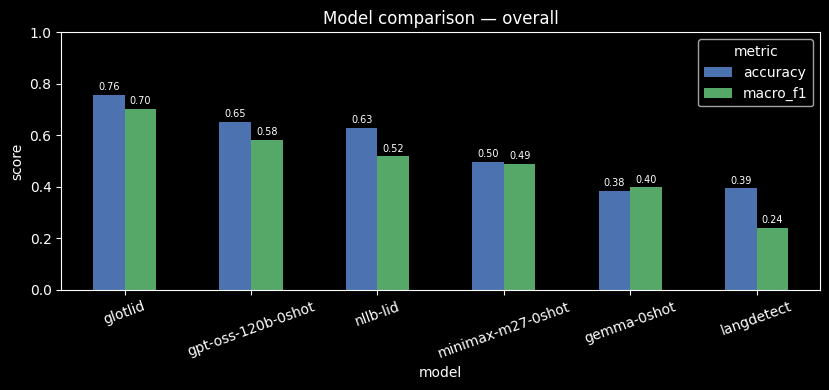

In [5]:
ax = plot_overview(runs)
plt.tight_layout()
fig_path = FIG_DIR / "overview.png"
ax.figure.savefig(fig_path, dpi=150, bbox_inches="tight")
print("saved", fig_path)
plt.show()

## Per-language comparison

Per-language scores for every model, side by side. Languages are sorted by `support` (most-represented first). Switch `METRIC` to `'recall'` or `'precision'` to compare on a different axis.

In [6]:
f1 = "f1"  # 'f1', 'recall', or 'precision'
recall = "recall"
precision = "precision"
METRIC = f1
pivot_f1 = per_language_pivot(runs, f1)
pivot_recall = per_language_pivot(runs, recall)
pivot_precision = per_language_pivot(runs, precision)

pivot_f1.to_csv(FIG_DIR / "per_language_f1.csv")
pivot_recall.to_csv(FIG_DIR / "per_language_recall.csv")
pivot_precision.to_csv(FIG_DIR / "per_language_precision.csv")

style_per_language(pivot_f1)

,model,support,gemma-0shot,glotlid,gpt-oss-120b-0shot,langdetect,minimax-m27-0shot,nllb-lid
name,lang,,,,,,,
Amharic,amh,200,0.77,0.96,0.96,0.00,0.84,0.96
Aragonese,arg,200,0.10,0.90,0.40,0.00,0.17,0.00
Arabic,ara,200,0.44,0.00,0.35,0.32,0.38,0.00
Ancient Hebrew,hbo,200,0.00,0.75,0.00,0.00,0.00,0.00
Bangla,ben,200,0.96,0.97,0.96,0.66,0.96,0.97
Bikol,bik,200,0.23,0.00,0.19,0.00,0.02,0.00
Assamese,asm,200,0.37,0.96,0.92,0.00,0.73,0.95
Crimean Tatar,crh,200,0.03,0.71,0.14,0.00,0.13,0.83
Central Bikol,bcl,200,0.01,0.65,0.02,0.00,0.02,0.00


### Per-language heatmap

/home/kostis/Projects/MDC/language-id/src/language_id/compare_experiments.py:267: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, cax = plt.subplots(figsize=figsize(n_chunk))


saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_01.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_02.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_03.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_04.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_05.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_06.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_07.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_08.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_09.png
saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap_10.png
saved /home/kostis/Projects/MDC/language-id/result

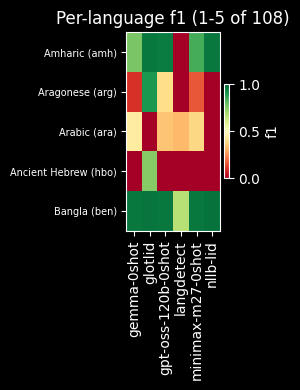

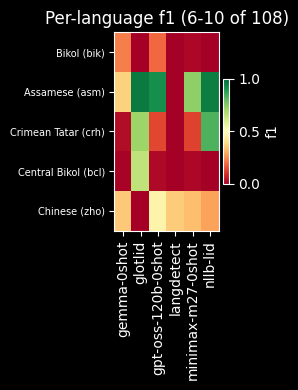

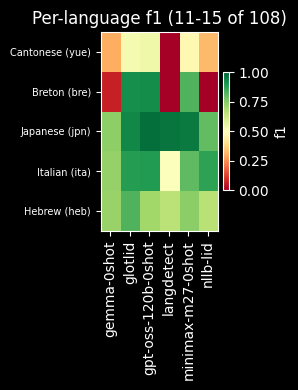

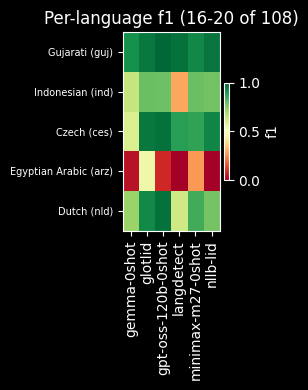

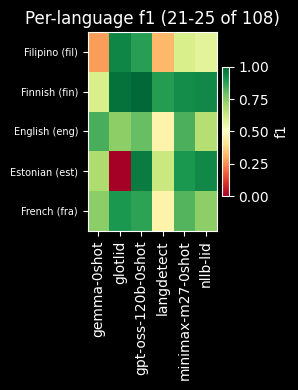

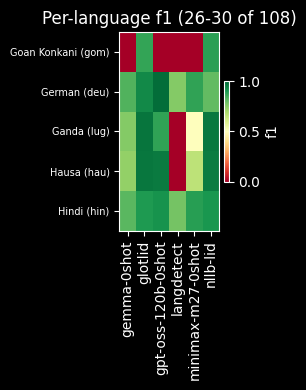

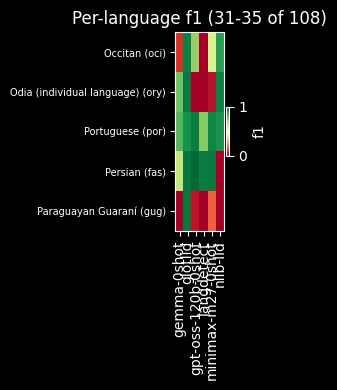

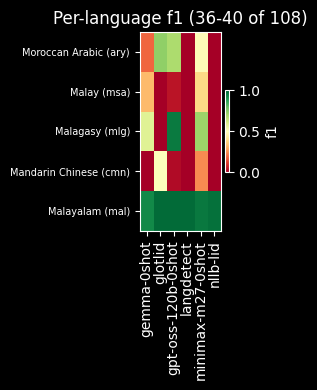

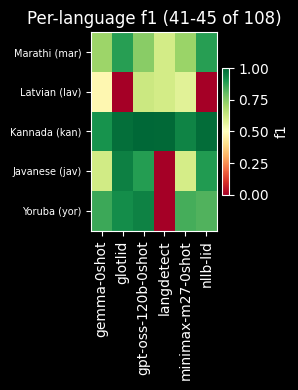

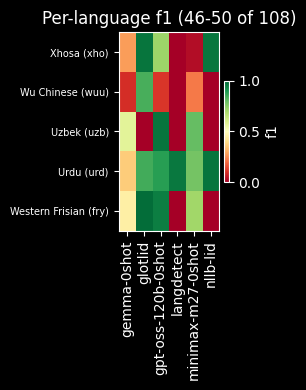

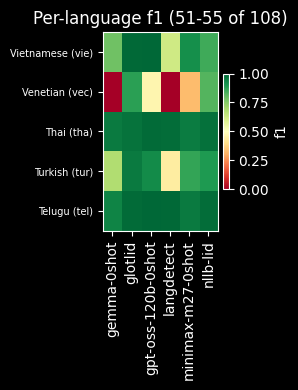

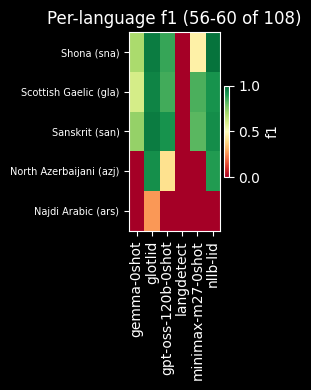

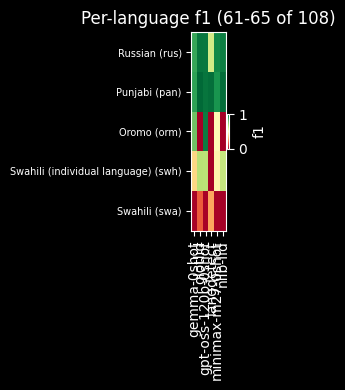

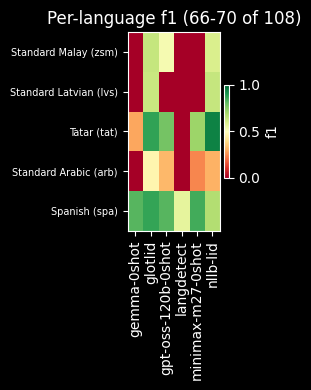

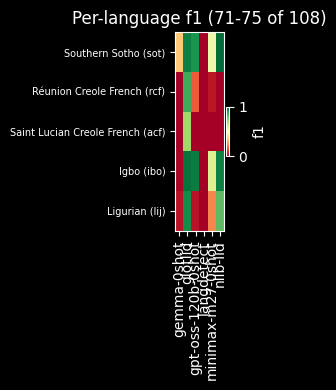

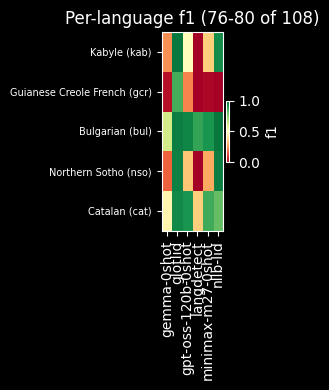

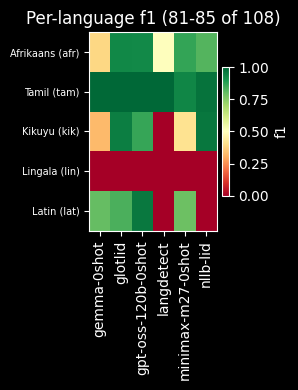

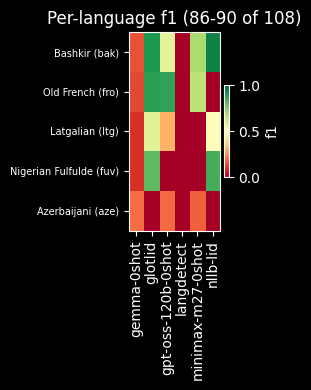

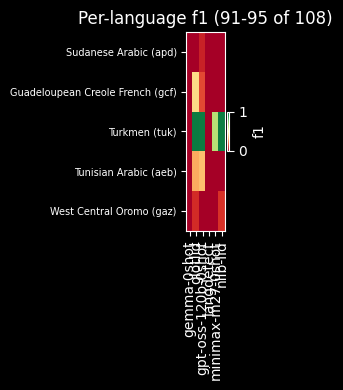

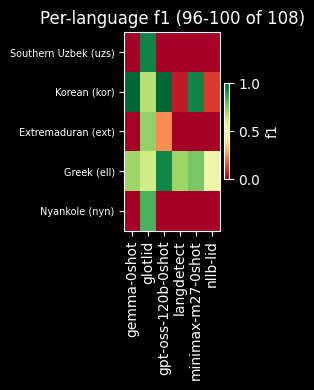

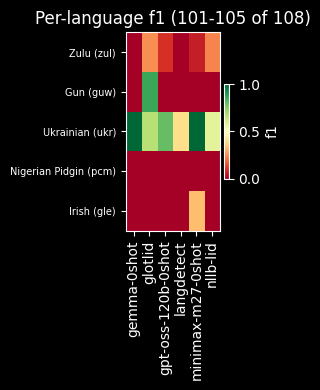

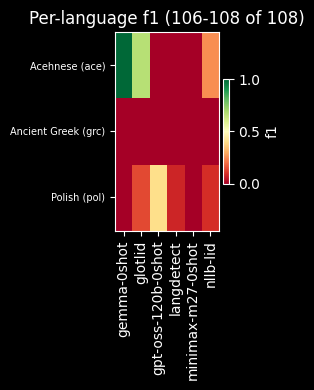

In [7]:
# Languages per heatmap figure; as many figures as needed are generated.
LANGS_PER_FIG = 5

axes = plot_per_language_heatmap(runs, METRIC, langs_per_fig=LANGS_PER_FIG, lang_axis="y")
for i, ax in enumerate(axes, start=1):
    ax.figure.tight_layout()
    fig_path = FIG_DIR / f"per_language_{METRIC}_heatmap_{i:02d}.png"
    ax.figure.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("saved", fig_path)
plt.show()

### Where models disagree most

Languages with the largest best-minus-worst spread across models i.e. where the choice of model matters most.

saved /home/kostis/Projects/MDC/language-id/results/comparisons/disagreement_f1.png


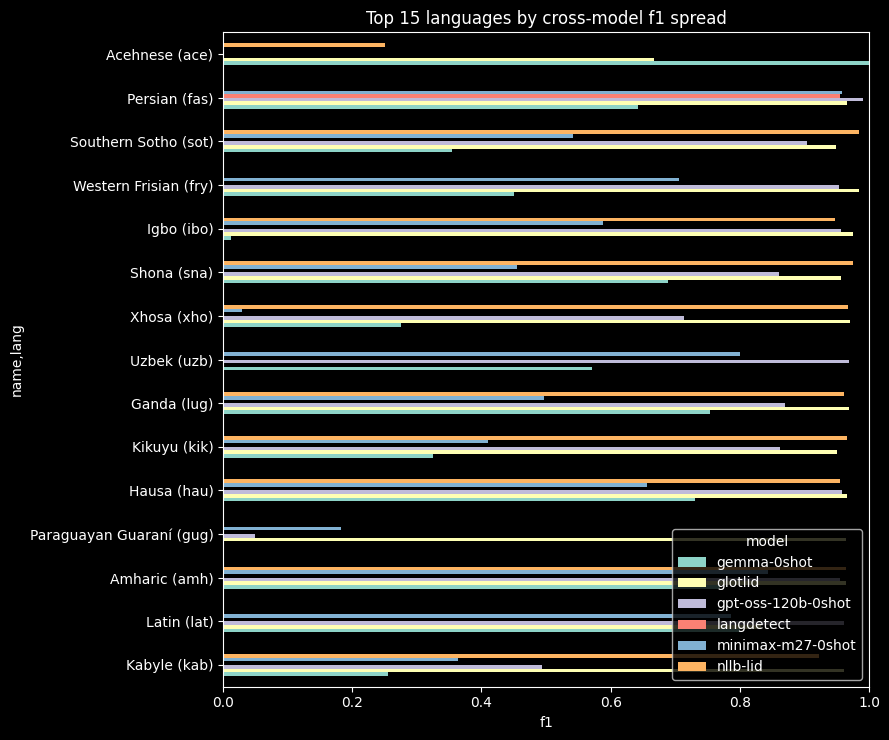

In [8]:
ax = plot_disagreement(runs, METRIC, top=15)
plt.tight_layout()
fig_path = FIG_DIR / f"disagreement_{METRIC}.png"
ax.figure.savefig(fig_path, dpi=150, bbox_inches="tight")
print("saved", fig_path)
plt.show()